# Optuna Hyperparameter Tuning for Direct GRU Architecture

This notebook implements hyperparameter optimization using Optuna for a Direct architecture with LSTM encoder.

In [ ]:
import optuna
import torch
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from torchmetrics import F1Score
import warnings
warnings.filterwarnings('ignore')

from GradientGang.Pipeline.DataLoader.DataLoader import DataModule
from GradientGang.Pipeline.Architectures.Direct import Direct

## 1. Setup Data Loaders

Keep data loading parameters fixed to focus on model architecture hyperparameters.

In [ ]:
# Fixed data loading parameters
data_params = {
    'data_dir': "../dataset/PirateProcessed/",
    'train_file_name': "pirate_pain_train.csv",
    'train_file_name_labels': "pirate_pain_train_labels.csv",
    'test_file_name': "pirate_pain_test.csv",
    'batch_size': 32,
    'num_workers': 0,
    'val_split': 0.2,
    'shuffle': True,
}

# Initialize data module
dataLoader = DataModule(params=data_params)
dataLoader.setup(stage='fit', includeTestInTrain=False)

trainLoader = dataLoader.train_dataloader()
valLoader = dataLoader.val_dataloader()

print("Data loaders initialized successfully!")
print(f"Training batches: {len(trainLoader)}")
print(f"Validation batches: {len(valLoader)}")

Data loaders initialized successfully!
Training batches: 17
Validation batches: 5


## 2. Define Architecture Parameter Generation

Create functions to generate architecture parameters for Direct GRU model based on Optuna trial suggestions.

In [ ]:
def create_architecture_params(trial,validation=True):
    """
    Create architecture parameters based on Optuna trial suggestions.
    
    Parameters to tune:
    - Learning rate
    - Regularization weight
    - GRU hidden size
    - GRU number of layers
    - Latent dimension (embedding size)
    - Activation functions
    - Feed-forward hidden layer sizes
    - Dropout rates
    - Bidirectional GRU
    """
    
    # Suggest hyperparameters
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    reg_weight = trial.suggest_float('regularization_weight', 1e-6, 0.5, log=True)
    
    # GRU parameters
    gru_hidden_size = trial.suggest_categorical('gru_hidden_size', [32, 64, 128, 256, 512])
    gru_num_layers = trial.suggest_int('gru_num_layers', 1, 4)
    gru_dropout = trial.suggest_float('gru_dropout', 0.0, 0.5) if gru_num_layers > 1 else 0.0
    
    # Latent dimension
    latent_dim = trial.suggest_categorical('latent_dim', [64, 128, 256, 512])
    
    # Activation functions
    encoder_activation = trial.suggest_categorical('encoder_activation', ['ReLU', 'GELU', 'LeakyReLU'])
    ff_activation = trial.suggest_categorical('ff_activation', ['ReLU', 'GELU', 'LeakyReLU'])
    
    # Feed-forward parameters
    ff_num_layers = trial.suggest_int('ff_num_layers', 1, 3)
    ff_hidden_size = trial.suggest_categorical('ff_hidden_size', [32, 64, 128, 256])
    ff_dropout = trial.suggest_float('ff_dropout', 0.0, 0.5)
    
    # Patience for early stopping
    patience = trial.suggest_int('patience', 5, 20)
    
    # Calculate actual GRU output size (doubles if bidirectional)
    gru_output_size = gru_hidden_size *2 
    
    # Build encoder layer configuration
    encoder_layers = [
        {
            "name": "GRU",
            "params": {
                "input_size": 34,
                "hidden_size": gru_hidden_size,
                "num_layers": gru_num_layers,
                "bias": True,
                "batch_first": True,
                "dropout": gru_dropout,
                "bidirectional": True
            }
        },
        {
            "name": "Linear",
            "params": {
                "in_features": gru_output_size,
                "out_features": latent_dim,
                "bias": True,
            }
        }
    ]
    
    # Build feed-forward layer configuration
    # Note: Direct.py will add the final output layer automatically
    ff_layers = []
    current_size = latent_dim + 1  # latent_dim + global_feature_size
    
    for i in range(ff_num_layers):
        # Add Linear layer
        ff_layers.append({
            "name": "Linear",
            "params": {
                "in_features": current_size,
                "out_features": ff_hidden_size,
                "bias": True,
            }
        })
        
        # Add Dropout layer after the Linear layer (not after the last one)
        if ff_dropout > 0 and i < ff_num_layers - 1:
            ff_layers.append({
                "name": "Dropout",
                "params": {
                    "p": ff_dropout
                }
            })
        
        current_size = ff_hidden_size
    
    # Build architecture parameters
    architecture_params = {
        "SchedulerMonitoringTarget": "val" if validation else "train",
        "LearningRate": learning_rate,
        "Patience": patience,
        "RegularizationWeight": reg_weight,
        "ClassWeightsPath": "../dataset/PirateProcessed/class_weights.yaml",
        "EncoderParams": {
            "activation_function": encoder_activation,
            "layer_type": encoder_layers
        },
        "FeedForwardParams": {
            "activation_function": ff_activation,
            "layer_type": ff_layers
        },
        "GlobalFFEncoderParams": {
            "activation_function": "LeakyReLU",
            "layer_type": [
                {
                    "name": "Linear",
                    "params": {
                        "in_features": 1,
                        "out_features": 1,
                        "bias": True,
                    }
                }
            ]
        },
        "OutputDim": 3
    }
    
    return architecture_params

## 3. Define Objective Function

The objective function trains the Direct model and returns the validation F1 score.

In [ ]:
def objective(trial):
    """
    Objective function for Optuna optimization.
    Returns validation F1 score to maximize.
    """
    
    # Generate architecture parameters from trial
    architecture_params = create_architecture_params(trial, validation=True)
    
    # Create model
    model = Direct(architecture_params)
    
    # Training parameters
    max_epochs = 300
    
    # Add early stopping callback
    early_stopping_callback = EarlyStopping(
        monitor='val_F1',
        patience=architecture_params["Patience"],
        mode='max',  # We want to maximize validation F1 score
        verbose=False
    )

    # Save best model checkpoint
    checkpoint_callback = ModelCheckpoint(
        monitor='val_F1',
        mode='max',
        save_top_k=5,
        filename='autoencoder-best-{epoch:02d}-{val_F1:.3f}',
        verbose=True
    )

    trainer = Trainer(
        max_epochs=max_epochs,
        enable_progress_bar=False,
        enable_model_summary=False,
        log_every_n_steps=20,
        callbacks=[early_stopping_callback, checkpoint_callback],
    )
    
    # Train the model
    try:
        trainer.fit(model, trainLoader, valLoader)
    except Exception as e:
        print(f"Trial {trial.number} failed with error: {e}")
        return 0.0
    
    # Store the epoch at which training stopped (for final training)
    best_epoch = trainer.current_epoch
    trial.set_user_attr('best_epoch', best_epoch)
    
    # Evaluate on validation set
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in valLoader:
            x, labels = batch
            preds = model(x)
            all_preds.extend(preds.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate F1 score
    f1_metric = F1Score(task="multiclass", num_classes=3, average='weighted')
    f1_score = f1_metric(torch.tensor(all_preds), torch.tensor(all_labels))
    
    # Handle pruning
    if trial.should_prune():
        raise optuna.TrialPruned()
    
    return f1_score.item()

## 4. Create and Run Optuna Study

Configure the study with pruning and run optimization.

In [ ]:
# Create study
study = optuna.create_study(
    direction='maximize',  # We want to maximize validation F1 score
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
    study_name='direct_gru_hyperparameter_tuning'
)

# Run optimization
n_trials = 100  # Number of trials to run
print(f"Starting optimization...")
print("This may take a while...\n")

study.optimize(objective, show_progress_bar=True)

print("\nOptimization complete!")

[I 2025-11-12 14:55:05,221] A new study created in memory with name: direct_gru_hyperparameter_tuning
[W 2025-11-12 14:55:05,223] Trial 0 failed with parameters: {'learning_rate': 0.0019710328238963966, 'regularization_weight': 0.012729126616799799, 'gru_hidden_size': 64, 'gru_num_layers': 4, 'gru_dropout': 0.4051920422960954, 'latent_dim': 256, 'encoder_activation': 'ReLU', 'ff_activation': 'GELU', 'ff_num_layers': 2, 'ff_hidden_size': 64, 'ff_dropout': 0.14874114643026515, 'patience': 11} because of the following error: KeyError("EncoderInterpreter: 'Gru' not found in interpretation dictionary.").
Traceback (most recent call last):
  File "c:\Users\marti\ANN-Challenges\.venv\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\marti\AppData\Local\Temp\ipykernel_24644\1333824329.py", line 11, in objective
    model = Direct(architecture_params)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^


Starting optimization...
This may take a while...



KeyError: "EncoderInterpreter: 'Gru' not found in interpretation dictionary."

## 5. Analyze Results

Display the best parameters and trial statistics.

In [ ]:
# Best trial information
print("=" * 80)
print("BEST TRIAL RESULTS")
print("=" * 80)
print(f"\nBest F1 Score: {study.best_trial.value:.4f}")
print(f"Best Trial Number: {study.best_trial.number}")
print("\nBest Hyperparameters:")
print("-" * 80)
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")
print("=" * 80)

# Store the best number of epochs for final training
best_trial_user_attrs = study.best_trial.user_attrs
best_num_epochs = best_trial_user_attrs.get('best_epoch', 60)
print(f"\nBest trial stopped at epoch: {best_num_epochs}")
print(f"This will be used for final training on full dataset.")

BEST TRIAL RESULTS

Best F1 Score: 0.8990
Best Trial Number: 0

Best Hyperparameters:
--------------------------------------------------------------------------------
  learning_rate: 0.0010709806476641068
  regularization_weight: 9.064207711010995e-05
  gru_hidden_size: 32
  gru_num_layers: 4
  gru_dropout: 0.013203977580833526
  bidirectional: False
  latent_dim: 512
  encoder_activation: ReLU
  ff_activation: GELU
  ff_num_layers: 1
  ff_hidden_size: 128
  ff_dropout: 0.12917940649875864
  patience: 16

Best trial stopped at epoch: 23
This will be used for final training on full dataset.


In [ ]:
# Summary statistics
print("\nStudy Statistics:")
print(f"  Number of finished trials: {len(study.trials)}")
print(f"  Number of pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print(f"  Number of complete trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")


Study Statistics:
  Number of finished trials: 3
  Number of pruned trials: 0
  Number of complete trials: 2


## 7. Train Final Model with Best Parameters

In [ ]:
# Create final model with best parameters
best_architecture_params = create_architecture_params(study.best_trial, validation=False)

final_model = Direct(best_architecture_params)

# Get the best number of epochs from the best trial
best_num_epochs = study.best_trial.user_attrs.get('best_epoch', 60)
print(f"Training final model for {best_num_epochs} epochs (same as best trial)")

# Train final model without validation
final_trainer = Trainer(
    max_epochs=best_num_epochs,
    enable_progress_bar=True,
)

data_params = {
    'data_dir': "../dataset/PirateProcessed/",
    'train_file_name': "pirate_pain_train.csv",
    'train_file_name_labels': "pirate_pain_train_labels.csv",
    'test_file_name': "pirate_pain_test.csv",
    'batch_size': 32,
    'num_workers': 0,
    'val_split': 0.0,
    'shuffle': True,
}

# Train final model on full dataset
full_dataloader = DataModule(params=data_params)
full_dataloader.setup(stage='fit', includeTestInTrain=False)
trainLoader = full_dataloader.train_dataloader()
valLoader = full_dataloader.val_dataloader()

print(f"Training final model with best hyperparameters on full dataset...")
print(f"Total training batches: {len(trainLoader)}")

final_trainer.fit(final_model, trainLoader, valLoader)
print(f"\nFinal model training complete after {best_num_epochs} epochs!")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training final model for 27 epochs (same as best trial)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                   | Type              | Params | Mode 
---------------------------------------------------------------------
0 | encoder                | Encoder           | 50.9 K | train
1 | globalff_encoder       | FeedForward       | 2      | train
2 | feedforward            | FeedForward       | 18.7 K | train
3 | f1Function             | MulticlassF1Score | 0      | train
4 | predictionLossFunction | CrossEntropyLoss  | 0      | train
---------------------------------------------------------------------
69.6 K    Trainable params
0         Non-trainable params
69.6 K    Total params
0.278     Total estimated model params size (MB)
22        Modules in train mode
0         Modules in eval mode

  | Name                   | Type              | Params | Mode 
---------------------------------------------------------------------
0 | encoder                | Encoder           | 50.9 K | train
1 | globalff_encoder       | FeedForward 

Training final model with best hyperparameters on full dataset...
Total training batches: 21


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=27` reached.



Final model training complete after 27 epochs!


## 8. Visualize Final Model Embeddings

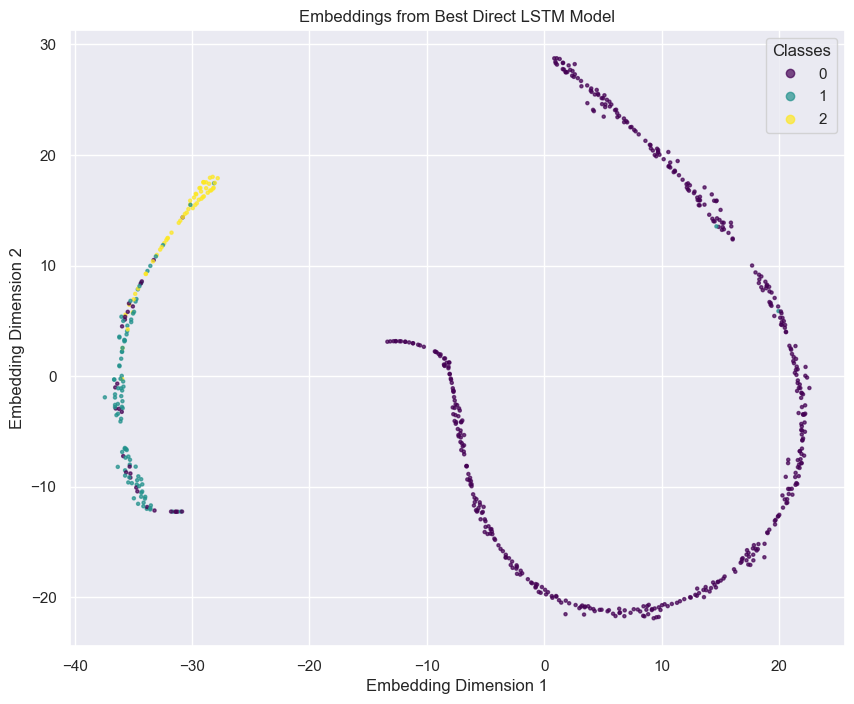

In [ ]:
# Plot embeddings from final model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
sns.set_theme()

embeddings = []
labels_list = []

final_model.eval()
with torch.no_grad():
    for batch in trainLoader:
        (time_series, global_features), labels = batch
        embedding = final_model.encoder(time_series)
        embeddings.append(embedding.cpu())
        labels_list.append(labels)

embeddings = torch.cat(embeddings, dim=0).numpy()
labels_list = torch.cat(labels_list, dim=0).numpy()

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_list, alpha=0.7, cmap='viridis', s=5)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('Embeddings from Best Direct LSTM Model')
plt.xlabel('Embedding Dimension 1')
plt.ylabel('Embedding Dimension 2')
plt.show()